In [1]:
import os
print('Initializing environment for Kaggle...')


Initializing environment for Kaggle...


In [2]:
# Install packages not pre-installed on Kaggle
%pip install -q vietocr jiwer


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.9/133.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 84.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import re
import time
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jiwer

# ── PIL._util compatibility patch ────────────────────────────────────────────
# Pillow ≥ 10.0 removed is_path / is_directory from PIL._util.
# torchvision (and vietocr) may call these functions. We patch them
# back BEFORE any import that loads torchvision or PIL, so this works
# regardless of which Pillow version is on sys.path.
try:
    from PIL._util import is_directory as _test_pil  # noqa: F401
except ImportError:
    import os as _os
    from PIL import _util as _pil_util
    if not hasattr(_pil_util, 'is_path'):
        _pil_util.is_path = lambda f: isinstance(f, (bytes, str, _os.PathLike))
    if not hasattr(_pil_util, 'is_directory'):
        _pil_util.is_directory = lambda f: (
            isinstance(f, (bytes, str, _os.PathLike)) and _os.path.isdir(f)
        )
    print('Applied PIL._util compatibility patch (Pillow >= 10 detected).')

# Now safe to import PIL and anything that chains through torchvision
from PIL import Image
import torch

# ── NumPy 2.0 compatibility patches ─────────────────────────────────────────
# Apply BEFORE importing vietocr.
if not hasattr(np, 'sctypes'):
    np.sctypes = {
        'int':     [np.int8, np.int16, np.int32, np.int64],
        'uint':    [np.uint8, np.uint16, np.uint32, np.uint64],
        'float':   [np.float16, np.float32, np.float64],
        'complex': [np.complex64, np.complex128],
        'others':  [np.bool_, np.bytes_, np.str_, np.object_, np.void,
                    np.datetime64, np.timedelta64],
    }
if not hasattr(np, 'bool'):
    np.bool = bool
if not hasattr(np, 'int'):
    np.int = int
if not hasattr(np, 'float'):
    np.float = float

from vietocr.tool.config import Cfg
from vietocr.tool.predictor import Predictor
from vietocr.model.trainer import Trainer

warnings.filterwarnings('ignore')
print(f'NumPy   : {np.__version__}')
from PIL import __version__ as _pv
print(f'Pillow  : {_pv}')
print(f'PyTorch : {torch.__version__}')
print('All imports OK.')


Applied PIL._util compatibility patch (Pillow >= 10 detected).
NumPy   : 2.0.2
Pillow  : 11.3.0
PyTorch : 2.10.0+cu128
All imports OK.


In [4]:
KAGGLE_ROOT = '/kaggle/input/datasets/ghtgfuiss123/vn-handwritten-ocr-dataset'

CONFIG = {
    # ── Paths ─────────────────────────────────────────────────────────────────
    'train_path'    : f'{KAGGLE_ROOT}/data/data/processed/experiment_B_train.txt',
    'val_path'      : f'{KAGGLE_ROOT}/data/data/processed/val.txt',
    'test_path'     : f'{KAGGLE_ROOT}/data/data/processed/test.txt',
    'metadata_path' : f'{KAGGLE_ROOT}/data/data/processed/experiment_B_filtered_metadata.json',
    'checkpoint_dir': '/kaggle/working/models/experiment_B/',

    # ── Data ──────────────────────────────────────────────────────────────────
    # Type A images (Dataset.zip unzipped by Kaggle)
    'image_root'         : f'{KAGGLE_ROOT}/Dataset/Dataset/data',
    
    # Type B images (crawled data from data.zip)
    'crawled_image_root' : f'{KAGGLE_ROOT}/data/data/crawled/detected_lines',

    'image_height'   : 32,
    'image_max_width': 690,
    'image_min_width': 32,
    'max_label_len'  : 180,
    'grayscale'      : True,

    # ── Model ─────────────────────────────────────────────────────────────────
    'backbone'  : 'vgg19_bn',
    'pretrained': True,

    # ── Training ──────────────────────────────────────────────────────────────
    'batch_size' : 32,
    'max_lr'     : 3e-4,
    'total_iters': 50000,
    'valid_every': 500,
    'log_every'  : 200,
    'device'     : 'cuda:0',
}

print('CONFIG loaded.')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')


CONFIG loaded.
  train_path: /kaggle/input/datasets/ghtgfuiss123/vn-handwritten-ocr-dataset/data/data/processed/experiment_B_train.txt
  val_path: /kaggle/input/datasets/ghtgfuiss123/vn-handwritten-ocr-dataset/data/data/processed/val.txt
  test_path: /kaggle/input/datasets/ghtgfuiss123/vn-handwritten-ocr-dataset/data/data/processed/test.txt
  metadata_path: /kaggle/input/datasets/ghtgfuiss123/vn-handwritten-ocr-dataset/data/data/processed/experiment_B_filtered_metadata.json
  checkpoint_dir: /kaggle/working/models/experiment_B/
  image_root: /kaggle/input/datasets/ghtgfuiss123/vn-handwritten-ocr-dataset/Dataset/Dataset/data
  crawled_image_root: /kaggle/input/datasets/ghtgfuiss123/vn-handwritten-ocr-dataset/data/data/crawled/detected_lines
  image_height: 32
  image_max_width: 690
  image_min_width: 32
  max_label_len: 180
  grayscale: True
  backbone: vgg19_bn
  pretrained: True
  batch_size: 32
  max_lr: 0.0003
  total_iters: 50000
  valid_every: 500
  log_every: 200
  device: cuda:0

In [5]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(59)
os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)

## 1. Load Processed Data

In [6]:
def read_annotation_file(filepath):
    '''Read a tab-separated annotation file.

    Each line format: <image_path><TAB><transcription>
    Returns a list of (image_path, transcription) tuples.
    '''
    entries = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.rstrip('\n')
            if not line.strip():
                continue
            parts = line.split('\t', maxsplit=1)
            if len(parts) != 2:
                print(f'WARNING: Skipping malformed line {line_num} in {filepath}')
                continue
            entries.append((parts[0].strip(), parts[1].strip()))
    return entries


def filter_by_label_len(entries, max_len):
    '''Drop entries whose transcription length exceeds max_len.'''
    kept = [(img, txt) for img, txt in entries if len(txt) <= max_len]
    return kept, len(entries) - len(kept)

In [7]:
train_data = read_annotation_file(CONFIG['train_path'])
val_data   = read_annotation_file(CONFIG['val_path'])
test_data  = read_annotation_file(CONFIG['test_path'])

print(f'Training text-lines  : {len(train_data):,}')
print(f'Validation text-lines: {len(val_data):,}')
print(f'Test samples         : {len(test_data):,}')

max_len = CONFIG['max_label_len']
train_data, train_dropped = filter_by_label_len(train_data, max_len)
val_data,   val_dropped   = filter_by_label_len(val_data,   max_len)
test_data,  test_dropped  = filter_by_label_len(test_data,  max_len)

print(f'\nmax_label_len guard ({max_len}):')
print(f'  Train dropped: {train_dropped:,}')
print(f'  Val dropped  : {val_dropped:,}')
print(f'  Test dropped : {test_dropped:,}')
print(f'\nAfter filtering:')
print(f'  Train samples: {len(train_data):,}')
print(f'  Val samples  : {len(val_data):,}')
print(f'  Test samples : {len(test_data):,}')

print('\nSample annotations (first 3):')
for img, txt in train_data[:3]:
    suffix = '...' if len(txt) > 80 else ''
    print(f'  {img}  ->  {txt[:80]}{suffix}')

Training text-lines  : 15,593
Validation text-lines: 1,636
Test samples         : 1,637

max_label_len guard (180):
  Train dropped: 0
  Val dropped  : 0
  Test dropped : 0

After filtering:
  Train samples: 15,593
  Val samples  : 1,636
  Test samples : 1,637

Sample annotations (first 3):
  data/UIT_HWDB_line_flat__40_4.jpg  ->  chưa di dời. Như vậy, trước thời điểm cấm xe tải nặng lưu thông ở nội ô vào ban
  data/VNOnDB_line__20160604_0199_25463_tg_0_3.png  ->  chiều 15 - 3 - 2004. Theo thông tin ban đầu, phía nạn nhân khai nhận với một số ...
  data/VNOnDB_line__20151111_0050_25439_2_tg_4_0.png  ->  Đề nghị anh Đại liên hệ với chúng tôi : Công ty Xây lắp & vật tư xây


## 2. Prepare Annotation Files

In [8]:
def write_annotation_file(entries, image_root, crawled_root, output_path):
    '''Write a VietOCR annotation file with resolved absolute image paths.

    experiment_B_train.txt stores paths in two formats:

      (A) 'data/<basename>'  — images from the zipped dataset
          resolved as: os.path.join(image_root, basename)
          e.g. /content/Dataset/data/UIT_HWDB_line_flat__40_4.jpg

      (B) '/home/khang/.../detected_lines/<file>'  — local absolute paths
          recorded during pseudo-labeling on WSL; on Colab these images
          live on Drive under crawled_root.
          resolved as: os.path.join(crawled_root, os.path.basename(img_path))
          e.g. /content/drive/MyDrive/Project/data/crawled/detected_lines/xxx.jpg

    Args:
        entries      : list of (img_path, transcription) as read from .txt
        image_root   : Colab path for dataset (A) images
        crawled_root : Colab/Drive path for crawled (B) images
        output_path  : destination .txt file
    '''
    abs_dataset  = os.path.abspath(image_root)
    abs_crawled  = os.path.abspath(crawled_root)
    parent_dir   = os.path.dirname(output_path)
    if parent_dir:
        os.makedirs(parent_dir, exist_ok=True)

    written = 0
    with open(output_path, 'w', encoding='utf-8') as f:
        for img_path, transcript in entries:
            if img_path.startswith('data/'):
                # Format (A): strip the 'data/' prefix then join with image_root
                basename = img_path[len('data/'):]
                abs_img  = os.path.join(abs_dataset, basename)
            elif os.path.isabs(img_path):
                # Format (B): local absolute path -> remap to crawled_root
                abs_img = os.path.join(abs_crawled, os.path.basename(img_path))
            else:
                # Fallback: treat as relative to image_root
                abs_img = os.path.join(abs_dataset, img_path)
            f.write(f'{abs_img}\t{transcript}\n')
            written += 1
    return output_path, written

In [9]:
# MUST write annotation files to /kaggle/working/ because KAGGLE_INPUT is read-only!
import os
os.makedirs('/kaggle/working/annotations', exist_ok=True)

train_annotation_path = '/kaggle/working/annotations/train_annotation.txt'
val_annotation_path   = '/kaggle/working/annotations/val_annotation.txt'

_, n_train = write_annotation_file(
    train_data,
    CONFIG['image_root'],
    CONFIG['crawled_image_root'],
    train_annotation_path,
)
_, n_val = write_annotation_file(
    val_data,
    CONFIG['image_root'],
    CONFIG['crawled_image_root'],
    val_annotation_path,
)

print(f'Training annotation  : {train_annotation_path}  ({n_train:,} entries)')
print(f'Validation annotation: {val_annotation_path}  ({n_val:,} entries)')

# Quick sanity check: verify a few resolved paths exist
print('\nPath sanity check (first 3 lines of train_annotation.txt):')
with open(train_annotation_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 3:
            break
        img_abs = line.split('\t')[0]
        exists  = os.path.isfile(img_abs)
        print(f'  [{"OK" if exists else "MISSING"}] {img_abs}')


Training annotation  : /kaggle/working/annotations/train_annotation.txt  (15,593 entries)
Validation annotation: /kaggle/working/annotations/val_annotation.txt  (1,636 entries)

Path sanity check (first 3 lines of train_annotation.txt):
  [OK] /kaggle/input/datasets/ghtgfuiss123/vn-handwritten-ocr-dataset/Dataset/Dataset/data/UIT_HWDB_line_flat__40_4.jpg
  [OK] /kaggle/input/datasets/ghtgfuiss123/vn-handwritten-ocr-dataset/Dataset/Dataset/data/VNOnDB_line__20160604_0199_25463_tg_0_3.png
  [OK] /kaggle/input/datasets/ghtgfuiss123/vn-handwritten-ocr-dataset/Dataset/Dataset/data/VNOnDB_line__20151111_0050_25439_2_tg_4_0.png


## 3. Build VietOCR Config

In [10]:
config = Cfg.load_config_from_name('vgg_seq2seq')

In [11]:
# ── Dataset ───────────────────────────────────────────────────────────────────
config['dataset']['data_root']        = ''   # annotation files use absolute paths
config['dataset']['name']             = 'vn_handwritten_ocr'
config['dataset']['train_annotation'] = os.path.abspath(train_annotation_path)
config['dataset']['valid_annotation'] = os.path.abspath(val_annotation_path)
config['dataset']['image_height']     = CONFIG['image_height']
config['dataset']['image_max_width']  = CONFIG['image_max_width']
config['dataset']['image_min_width']  = CONFIG['image_min_width']

# ── Optimizer & training loop ──────────────────────────────────────────────────
config['trainer']['batch_size']  = CONFIG['batch_size']
config['trainer']['iters']       = CONFIG['total_iters']
config['trainer']['valid_every'] = CONFIG['valid_every']
config['trainer']['print_every'] = CONFIG['log_every']
config['optimizer']['max_lr']    = CONFIG['max_lr']

# ── Checkpoint / log paths ─────────────────────────────────────────────────────
checkpoint_dir_abs = os.path.abspath(CONFIG['checkpoint_dir'])
os.makedirs(checkpoint_dir_abs, exist_ok=True)

config['trainer']['export']     = os.path.join(checkpoint_dir_abs, 'best_model.pth')
config['trainer']['log']        = os.path.join(checkpoint_dir_abs, 'training_log')
config['trainer']['checkpoint'] = os.path.join(checkpoint_dir_abs, 'last_checkpoint.pth')

# ── Device & backbone ──────────────────────────────────────────────────────────
config['device']   = CONFIG['device']
config['backbone'] = CONFIG['backbone']   # explicitly override default

# ── Summary ────────────────────────────────────────────────────────────────────
print('=' * 60)
print('VietOCR Configuration Summary')
print('=' * 60)
for section_name in ['dataset', 'transformer', 'optimizer', 'trainer']:
    if section_name in config:
        print(f'\n[{section_name}]')
        section = config[section_name]
        if isinstance(section, dict):
            for k, v in section.items():
                print(f'  {k}: {v}')
        else:
            print(f'  {section}')
print(f'\nbackbone: {config.get("backbone", "N/A")}')
print(f'device  : {config.get("device", "N/A")}')
print('=' * 60)

VietOCR Configuration Summary

[dataset]
  name: vn_handwritten_ocr
  data_root: 
  train_annotation: /kaggle/working/annotations/train_annotation.txt
  valid_annotation: /kaggle/working/annotations/val_annotation.txt
  image_height: 32
  image_min_width: 32
  image_max_width: 690

[transformer]
  encoder_hidden: 256
  decoder_hidden: 256
  img_channel: 256
  decoder_embedded: 256
  dropout: 0.1

[optimizer]
  max_lr: 0.0003
  pct_start: 0.1

[trainer]
  batch_size: 32
  print_every: 200
  valid_every: 500
  iters: 50000
  export: /kaggle/working/models/experiment_B/best_model.pth
  checkpoint: /kaggle/working/models/experiment_B/last_checkpoint.pth
  log: /kaggle/working/models/experiment_B/training_log
  metrics: None

backbone: vgg19_bn
device  : cuda:0


## 4. Initialize Trainer

In [12]:
# Remove stale LMDB directories to avoid 'already open' / lock errors.
# Note: folder name is '{split}_{dataset_name}'
for folder in ['train_vn_handwritten_ocr', 'valid_vn_handwritten_ocr', 'train_data', 'valid_data']:
    if os.path.exists(folder):
        try:
            shutil.rmtree(folder)
            print(f'Removed {folder}')
        except Exception as e:
            print(f'Could not remove {folder}: {e}')

In [13]:
class Custom_Trainer(Trainer):
    '''VietOCR Trainer with:
    - Resilient DataLoader iteration (auto-restarts on exhaustion)
    - Checkpoint saved at every log step AND on any exit via finally block
    - Best model saved whenever validation full-sequence accuracy improves
    '''

    def __init__(self, config, pretrained=True):
        super().__init__(config, pretrained)

    def train(self):
        total_loss        = 0
        total_loader_time = 0
        total_gpu_time    = 0
        best_acc          = 0

        data_iter = iter(self.train_gen)

        try:
            for i in range(self.num_iters):
                self.iter += 1

                # ── Data loading ───────────────────────────────────────────────
                t0 = time.time()
                try:
                    batch = next(data_iter)
                except StopIteration:
                    data_iter = iter(self.train_gen)
                    batch     = next(data_iter)
                total_loader_time += time.time() - t0

                # ── Forward / backward ─────────────────────────────────────────
                t0   = time.time()
                loss = self.step(batch)
                total_gpu_time += time.time() - t0

                total_loss += loss
                self.train_losses.append((self.iter, loss))

                # ── Periodic log + checkpoint ──────────────────────────────────
                if self.iter % self.print_every == 0:
                    info = (
                        'iter: {:06d} - train loss: {:.3f} - lr: {:.2e}'
                        ' - load time: {:.2f} - gpu time: {:.2f}'.format(
                            self.iter,
                            total_loss / self.print_every,
                            self.optimizer.param_groups[0]['lr'],
                            total_loader_time,
                            total_gpu_time,
                        )
                    )
                    total_loss        = 0
                    total_loader_time = 0
                    total_gpu_time    = 0

                    print(info)
                    self.logger.log(info)

                    if self.checkpoint:
                        print('>>> Auto-saving checkpoint...')
                        self.save_checkpoint(self.checkpoint)

                # ── Validation ─────────────────────────────────────────────────
                if self.valid_annotation and self.iter % self.valid_every == 0:
                    val_loss = self.validate()
                    acc_full_seq, acc_per_char = self.precision(self.metrics)

                    info = (
                        'iter: {:06d} - valid loss: {:.3f}'
                        ' - acc full seq: {:.4f} - acc per char: {:.4f}'.format(
                            self.iter, val_loss, acc_full_seq, acc_per_char
                        )
                    )
                    print(info)
                    self.logger.log(info)

                    if acc_full_seq > best_acc:
                        self.save_weights(self.export_weights)
                        best_acc = acc_full_seq

        finally:
            # Save checkpoint on any exit (timeout, crash, KeyboardInterrupt)
            if self.checkpoint:
                try:
                    print('>>> Saving final checkpoint before exit...')
                    self.save_checkpoint(self.checkpoint)
                except Exception as exc:
                    print('Failed to save final checkpoint:', exc)

In [14]:
trainer = Custom_Trainer(config, pretrained=CONFIG['pretrained'])

Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:02<00:00, 233MB/s]
10935it [00:10, 1057.78it/s]
Create train_vn_handwritten_ocr: 100%|████████████████████████| 15593/15593 [02:57<00:00, 88.00it/s]


Created dataset with 15592 samples


Create valid_vn_handwritten_ocr: 100%|██████████████████████████| 1636/1636 [00:17<00:00, 92.34it/s]


Created dataset with 1635 samples


valid_vn_handwritten_ocr build cluster: 100%|███████████████| 1635/1635 [00:00<00:00, 189041.98it/s]


## 5. Training

In [15]:
print('Starting training...')
print(f"  Total iterations : {CONFIG['total_iters']:,}")
print(f"  Batch size       : {CONFIG['batch_size']}")
print(f"  Validate every   : {CONFIG['valid_every']:,} iters")
print(f"  Log every        : {CONFIG['log_every']} iters")
print(f"  Device           : {CONFIG['device']}")
print('=' * 60)

# Protect against empty dataset issues (StopIteration crash)
if hasattr(trainer, 'train_gen') and len(trainer.train_gen.dataset) == 0:
    raise ValueError("❌ Training dataset is EMPTY! The image paths in train_annotation.txt likely do not exist on disk. Did you forget to unzip the dataset or verify Google Drive paths?")

try:
    trainer.train()
    print('\nTraining completed successfully!')
except KeyboardInterrupt:
    # Custom_Trainer.train() already saves via its finally block;
    # saving again here is harmless.
    print('\nTraining interrupted by user.')
    trainer.save_checkpoint(config['trainer']['checkpoint'])
except Exception as e:
    print(f'\nTraining failed with error: {e}')
    raise

Starting training...
  Total iterations : 50,000
  Batch size       : 32
  Validate every   : 500 iters
  Log every        : 200 iters
  Device           : cuda:0
iter: 000200 - train loss: 1.302 - lr: 1.31e-05 - load time: 0.45 - gpu time: 153.18
>>> Auto-saving checkpoint...
iter: 000400 - train loss: 1.130 - lr: 1.65e-05 - load time: 0.06 - gpu time: 151.37
>>> Auto-saving checkpoint...
iter: 000500 - valid loss: 1.010 - acc full seq: 0.0033 - acc per char: 0.4543
iter: 000600 - train loss: 1.061 - lr: 2.21e-05 - load time: 1.07 - gpu time: 149.69
>>> Auto-saving checkpoint...
iter: 000800 - train loss: 1.015 - lr: 2.98e-05 - load time: 0.06 - gpu time: 153.38
>>> Auto-saving checkpoint...
iter: 001000 - train loss: 0.995 - lr: 3.95e-05 - load time: 0.65 - gpu time: 150.75
>>> Auto-saving checkpoint...
iter: 001000 - valid loss: 0.924 - acc full seq: 0.0100 - acc per char: 0.5595
iter: 001200 - train loss: 0.949 - lr: 5.10e-05 - load time: 0.07 - gpu time: 152.00
>>> Auto-saving che

## 6. Post-Training: Visualize Metrics

Found training log at: /kaggle/working/models/experiment_B/training_log


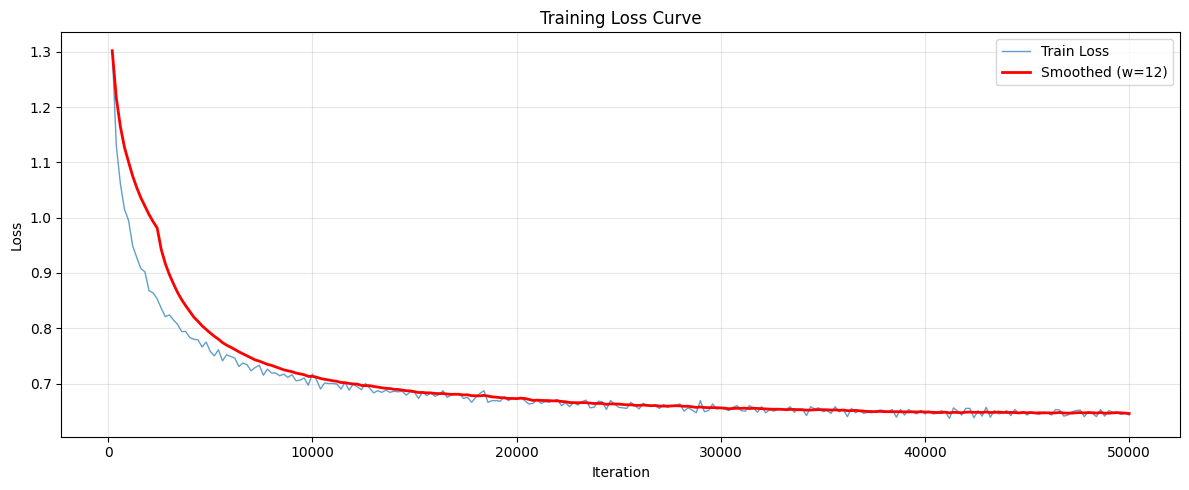

Metrics saved to: /kaggle/working/models/experiment_B/metrics.csv

Metrics summary:
          iteration        loss
count    250.000000  250.000000
mean   25100.000000    0.689628
std    14462.595433    0.080660
min      200.000000    0.637000
25%    12650.000000    0.651000
50%    25100.000000    0.661000
75%    37550.000000    0.688750
max    50000.000000    1.302000


In [16]:
log_dir = config['trainer']['log']

# VietOCR may write the log to slightly different locations; check all.
log_file_candidates = [
    log_dir,
    log_dir + '.log',
    os.path.join(log_dir, 'train.log'),
    os.path.join(checkpoint_dir_abs, 'train.log'),
]

log_content = None
for candidate in log_file_candidates:
    if os.path.isfile(candidate):
        with open(candidate, 'r', encoding='utf-8') as f:
            log_content = f.read()
        print(f'Found training log at: {candidate}')
        break

metrics_records = []

# 1. Parse train-loss lines from log file
if log_content:
    train_pattern = re.compile(
        r'iter:\s*(\d+)\s*-\s*train loss:\s*([\d.]+)',
        re.IGNORECASE,
    )
    for iter_str, loss_str in train_pattern.findall(log_content):
        metrics_records.append({'iteration': int(iter_str), 'loss': float(loss_str)})

# 2. Fallback: trainer.train_losses  [(iter, loss), ...]
if not metrics_records and hasattr(trainer, 'train_losses') and trainer.train_losses:
    print('Using trainer.train_losses as fallback')
    for item in trainer.train_losses:
        if isinstance(item, (list, tuple)) and len(item) == 2:
            try:
                metrics_records.append({'iteration': int(item[0]), 'loss': float(item[1])})
            except Exception:
                continue

# 3. Build DataFrame and plot
if metrics_records:
    df_metrics = (
        pd.DataFrame(metrics_records)
        .drop_duplicates(subset='iteration')
        .sort_values('iteration')
        .reset_index(drop=True)
    )
    df_metrics['iteration'] = pd.to_numeric(df_metrics['iteration'], errors='coerce')
    df_metrics['loss']      = pd.to_numeric(df_metrics['loss'],      errors='coerce')
    df_metrics = df_metrics.dropna()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df_metrics['iteration'], df_metrics['loss'],
            linewidth=1, alpha=0.7, label='Train Loss')

    window = max(1, len(df_metrics) // 20)
    if len(df_metrics) > window:
        smoothed = df_metrics['loss'].rolling(window=window, min_periods=1).mean()
        ax.plot(df_metrics['iteration'], smoothed,
                linewidth=2, color='red', label=f'Smoothed (w={window})')

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.set_title('Training Loss Curve')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(checkpoint_dir_abs, 'loss_curve.png'), dpi=150)
    plt.show()

    metrics_csv_path = os.path.join(checkpoint_dir_abs, 'metrics.csv')
    df_metrics.to_csv(metrics_csv_path, index=False)
    print(f'Metrics saved to: {metrics_csv_path}')
    print('\nMetrics summary:')
    print(df_metrics.describe())
else:
    print('No training metrics found.')
    df_metrics       = pd.DataFrame(columns=['iteration', 'loss'])
    metrics_csv_path = os.path.join(checkpoint_dir_abs, 'metrics.csv')
    df_metrics.to_csv(metrics_csv_path, index=False)
    print(f'Empty metrics CSV saved to: {metrics_csv_path}')

## 7. Test Evaluation

In [17]:
def _resolve_image_path(image_path, image_root):
    '''Return the absolute path for a test-set image entry.

    test.txt entries may carry a 'data/' prefix (e.g. 'data/img.jpg') because
    of how the dataset split files were originally created.  Since image_root
    already points to the 'data/' sub-directory (/content/Dataset/data),
    stripping the prefix before joining avoids the doubled path component
    '/content/Dataset/data/data/img.jpg'.

    Examples  (image_root = '/content/Dataset/data'):
        'data/img.jpg'  ->  '/content/Dataset/data/img.jpg'
        'img.jpg'       ->  '/content/Dataset/data/img.jpg'
    '''
    rel = image_path[len('data/'):] if image_path.startswith('data/') else image_path
    return os.path.join(os.path.abspath(image_root), rel)


def compute_cer(predictions, ground_truths):
    '''Character Error Rate; pairs with empty ground truth are skipped.'''
    assert len(predictions) == len(ground_truths)
    preds, gts = [], []
    for pred, gt in zip(predictions, ground_truths):
        gt_clean = gt.strip()
        if not gt_clean:
            continue
        preds.append(pred.strip())
        gts.append(gt_clean)
    return float(jiwer.cer(gts, preds)) if gts else 0.0


def compute_wer(predictions, ground_truths):
    '''Word Error Rate; pairs with empty ground truth are skipped.'''
    assert len(predictions) == len(ground_truths)
    preds, gts = [], []
    for pred, gt in zip(predictions, ground_truths):
        gt_clean = gt.strip()
        if not gt_clean or not gt_clean.split():
            continue
        preds.append(pred.strip())
        gts.append(gt_clean)
    return float(jiwer.wer(gts, preds)) if gts else 0.0

In [18]:
best_model_path = config['trainer']['export']

if os.path.isfile(best_model_path):
    print(f'Loading best model from: {best_model_path}')

    pred_config = Cfg.load_config_from_name('vgg_seq2seq')
    pred_config['dataset']['image_height']    = CONFIG['image_height']
    pred_config['dataset']['image_max_width'] = CONFIG['image_max_width']
    pred_config['dataset']['image_min_width'] = CONFIG['image_min_width']
    pred_config['weights'] = best_model_path
    pred_config['device']  = CONFIG['device']

    predictor = Predictor(pred_config)
    print('Predictor initialized.')

    predictions, ground_truths, image_paths, errors = [], [], [], []
    use_grayscale = CONFIG['grayscale']

    for img_rel_path, gt_text in test_data:
        img_full_path = _resolve_image_path(img_rel_path, CONFIG['image_root'])
        try:
            img = Image.open(img_full_path)
            img = img.convert('L').convert('RGB') if use_grayscale else img.convert('RGB')
            predictions.append(predictor.predict(img))
            ground_truths.append(gt_text)
            image_paths.append(img_rel_path)
        except FileNotFoundError:
            errors.append((img_rel_path, 'FileNotFoundError'))
        except Exception as e:
            errors.append((img_rel_path, str(e)))

    if predictions:
        test_cer = compute_cer(predictions, ground_truths)
        test_wer = compute_wer(predictions, ground_truths)

        df_results = pd.DataFrame({
            'image'       : image_paths,
            'ground_truth': ground_truths,
            'prediction'  : predictions,
        })
        df_results['exact_match'] = (
            df_results['prediction'].str.strip() == df_results['ground_truth'].str.strip()
        )

        exact_match     = int(df_results['exact_match'].sum())
        exact_match_pct = exact_match / len(df_results) * 100

        print(f'\nTest Evaluation ({len(df_results):,} samples):')
        print(f'  CER          : {test_cer:.4f}  ({test_cer * 100:.2f}%)')
        print(f'  WER          : {test_wer:.4f}  ({test_wer * 100:.2f}%)')
        print(f'  Exact matches: {exact_match}/{len(df_results)} ({exact_match_pct:.2f}%)')
        print(f'  Load errors  : {len(errors):,}')
        if use_grayscale:
            print('  Grayscale    : enabled  (L -> RGB)')

        test_eval_csv = os.path.join(checkpoint_dir_abs, 'test_predictions.csv')
        df_results.to_csv(test_eval_csv, index=False, encoding='utf-8')
        print(f'\nResults saved to: {test_eval_csv}')

        if errors:
            print('\nFirst 5 load errors:')
            for p, e in errors[:5]:
                print(f'  {p}: {e}')
    else:
        print('No valid predictions generated. Check image paths in test.txt.')
else:
    print(f'Best model not found at: {best_model_path}')
    print('Re-run this cell after training completes.')

Loading best model from: /kaggle/working/models/experiment_B/best_model.pth
Predictor initialized.

Test Evaluation (1,637 samples):
  CER          : 0.0298  (2.98%)
  WER          : 0.0792  (7.92%)
  Exact matches: 762/1637 (46.55%)
  Load errors  : 0
  Grayscale    : enabled  (L -> RGB)

Results saved to: /kaggle/working/models/experiment_B/test_predictions.csv
